# **Evaluación 1 - Machine Learning**


## **Sección 1**

Genere las siguientes imágenes de manera sintética. \\

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

In [1]:
# Import some libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from google.colab.patches import cv2_imshow

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### **Ejercicio 1 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1Z3yNgkQVFJyaCRyTzkjFhIB_3kxqs61q/view?usp=drive_link). \\
**NOTA:** En la salida de la celda puede encontrar el tamaño de la imagen final.


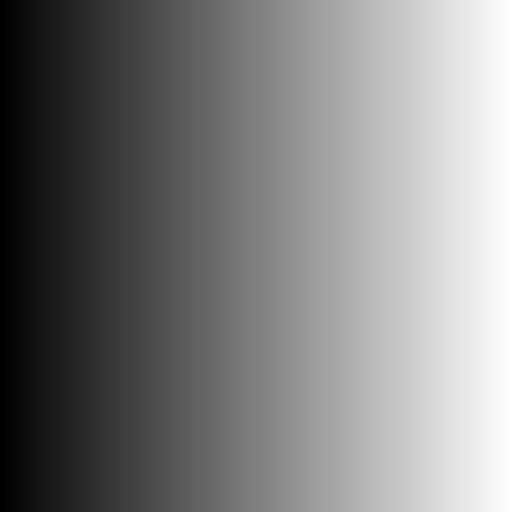

In [5]:
ancho = 512
alto = 512

columna = (np.arange(ancho, dtype=np.float32) * 255 / (ancho - 1)).astype(np.uint8)
img = np.repeat(columna[np.newaxis, :], alto, axis=0)

cv2_imshow(img)

### **Ejercicio 2 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/13z0tvGYD-37_PuHOqoRWHGGmGq7xxvU7/view?usp=drive_link).


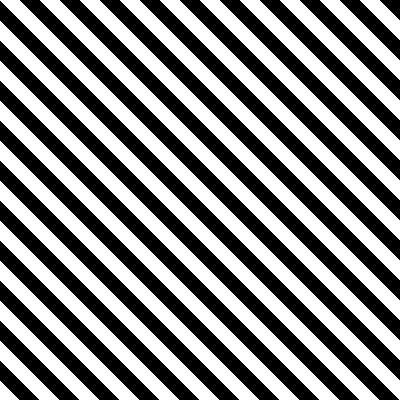

In [6]:
size = 400
ancho_franja = 20

columnas = np.arange(size)
filas = np.arange(size)

X, Y = np.meshgrid(columnas, filas)
patron = ((X - Y + size) // ancho_franja) % 2

img = np.zeros((size, size), dtype=np.uint8)
img[patron == 0] = 255

cv2_imshow(img)

## **Sección 2**

Genere las siguientes imágenes usando recorridos por píxeles a partir de [lena.jpg](https://drive.google.com/file/d/1gH5sJN__2g7f9ndLhLvTECdOBJIGUbg_/view?usp=sharing)  y [bengal_tiger.jpg](https://drive.google.com/file/d/1oz8CWUjN7UBNJNq1XOxqzwmYcJRTRmxr/view?usp=sharing)

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

### **Ejercicio 3 (C = 1.6)**

Genere la siguiente animación [resultado](https://drive.google.com/file/d/1jSNhV2CYdm6-E5wuo7o5wE-b2J-_mEil/view?usp=drive_link).

In [12]:


lena = cv2.imread('/content/drive/MyDrive/MachineLearning/lena.jpg')
tigre = cv2.imread('/content/drive/MyDrive/MachineLearning/tigre.jpg')

if lena is None or tigre is None:
    print("No se pudieron cargar las imágenes.")
    print("Lena cargada:", lena is not None)
    print("Tigre cargado:", tigre is not None)

else:
    alto = min(lena.shape[0], tigre.shape[0])
    ancho = min(lena.shape[1], tigre.shape[1])

    imgA = lena[:alto, :ancho].astype(np.float32)
    imgB = tigre[:alto, :ancho].astype(np.float32)

    lista_frames = []
    total_frames = 30

    for paso in range(total_frames + 1):

        factor = paso / total_frames
        mezcla = (1 - factor) * imgA + factor * imgB

        frame = mezcla.astype(np.uint8)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        lista_frames.append(frame_rgb)

    frames_reversa = lista_frames[::-1][1:-1]
    animacion = lista_frames + frames_reversa

    archivo_salida = "transicion_lena_tigre.gif"

    imageio.mimsave(archivo_salida, animacion, fps=20, loop=0)

    print("GIF generado correctamente:", archivo_salida)

GIF generado correctamente: transicion_lena_tigre.gif


### **Ejercicio 4 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1UX2Y8Q2xWy5ej0hl_r1B-fKAQ8SX5DI1/view?usp=drive_link).


Tamaño de la imagen: (300, 400, 3)


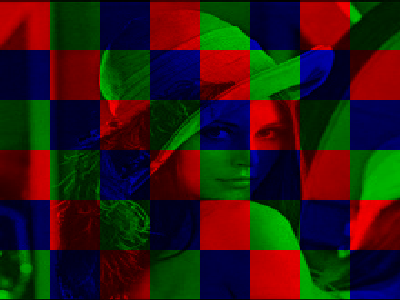

In [13]:
lena = cv2.imread('/content/drive/MyDrive/MachineLearning/lena.jpg')

if lena is None:
    print("Error: no se pudo cargar lena.jpg")
else:

    alto_salida = 300
    ancho_salida = 400

    alto_original, ancho_original, canales = lena.shape

    lena_redim = np.zeros((alto_salida, ancho_salida, 3), dtype=np.uint8)

    for i in range(alto_salida):
        for j in range(ancho_salida):

            oi = int(i * alto_original / alto_salida)
            oj = int(j * ancho_original / ancho_salida)

            if oi >= alto_original:
                oi = alto_original - 1
            if oj >= ancho_original:
                oj = ancho_original - 1

            lena_redim[i, j, 0] = lena[oi, oj, 0]
            lena_redim[i, j, 1] = lena[oi, oj, 1]
            lena_redim[i, j, 2] = lena[oi, oj, 2]

    resultado = np.zeros((alto_salida, ancho_salida, 3), dtype=np.uint8)

    filas_bloques = 6
    columnas_bloques = 8

    alto_bloque = alto_salida // filas_bloques   # 300/6 = 50
    ancho_bloque = ancho_salida // columnas_bloques  # 400/8 = 50

    canales_patron = [2, 1, 0]

    for i in range(alto_salida):
        for j in range(ancho_salida):
            fila_bloque = i // alto_bloque
            col_bloque = j // ancho_bloque

            patron = (col_bloque - fila_bloque) % 3
            canal_activo = canales_patron[patron]

            resultado[i, j, canal_activo] = lena_redim[i, j, canal_activo]

    print("Tamaño de la imagen:", resultado.shape)
    cv2_imshow(resultado)

### **Ejercicio 5 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/10jxoa_muSn6bxsDBy7Vw88wz1oirMiRH/view?usp=drive_link)

Tamaño de la imagen: (300, 400, 3)


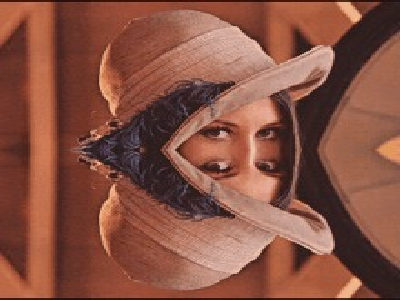

In [14]:
lena = cv2.imread('/content/drive/MyDrive/MachineLearning/lena.jpg')

if lena is None:
    print("Error: no se pudo cargar lena.jpg")
else:

    alto_salida = 300
    ancho_salida = 400

    alto_original, ancho_original, canales = lena.shape

    lena_redim = np.zeros((alto_salida, ancho_salida, 3), dtype=np.uint8)

    for i in range(alto_salida):
        for j in range(ancho_salida):
            oi = int(i * alto_original / alto_salida)
            oj = int(j * ancho_original / ancho_salida)

            if oi >= alto_original:
                oi = alto_original - 1
            if oj >= ancho_original:
                oj = ancho_original - 1

            for c in range(3):
                lena_redim[i, j, c] = lena[oi, oj, c]

    resultado = np.zeros((alto_salida, ancho_salida, 3), dtype=np.uint8)

    mitad = alto_salida // 2

    for i in range(mitad):
        for j in range(ancho_salida):
            for c in range(3):
                resultado[i, j, c] = lena_redim[i, j, c]

    for i in range(mitad, alto_salida):
        fila_espejo = alto_salida - 1 - i

        for j in range(ancho_salida):
            for c in range(3):
                resultado[i, j, c] = lena_redim[fila_espejo, j, c]

    print("Tamaño de la imagen:", resultado.shape)
    cv2_imshow(resultado)